# Convert Kinetics Library to Training Reactions Script

Specify the kinetics library name below and run the script.  It automatically overwrites the training reactions files it needs to.  Then you should commit those files.

This script only trains safely.  In other words, if a single match from an RMG family is found, a training reaction is created.  Sometimes, there are no matches from RMG reaction families, or multiple matches.  This indicates an error that requires manual fixing, and a printout is given in the script.

In [1]:
# Set libraries to load reactions from; set to None to load all libraries
libraries = ['PFAS_HPL_Test/bandaid_testing']

# Set families to add training reactions to; either 'default' or a list, e.g. ['R_Addition_MultipleBond']
families = ['default', 'halogens', 'PFAS']

PFAS_families = ['CO_CF_bond_dissociation',
                 'PFAS_Hydrolysis', 
                 'Lactone_Formation',
                 'CO2_Elimination_From_Carboxylic_Acid',
                 'Perfluoroalkene_Formation',
                 'Enol_Ether_Formation',
    
                 '1+2_Cycloaddition',
                 'XY_Addition_MultipleBond',
                 'R_Addition_MultipleBond',
                 '1,2_Insertion_CO', 
                 '1,3_Insertion_CO2',
                 '1,3_sigmatropic_rearrangement',
                 'R_Addition_COm',
                 'F_Abstraction', 
]

# Specify whether to plot kinetics comparisons
compare_kinetics = True

# Specify whether to print library reactions which don't fit in the specified families
# This can result in a lot of unnecessary output if only using a few families
show_all = True

# Specify whether to prioritize aromatic resonance structures to reduce cases of multiple matches
filter_aromatic = True

# Specify whether to use verbose comments when averaging tree
verbose_comments = True

In [2]:
from rmgpy import settings
from rmgpy.data.rmg import RMGDatabase
from kinetics_library_to_training_tools_modified import *
from base64 import b64encode
from IPython.display import display, HTML
from rmgpy.reaction import Reaction
from rmgpy.species import Species
from rmgpy.molecule import Molecule


In [3]:
thermolibs = [
'C1_C2_Fluorine', #adding Siddha's as first most trusted because this is the thermo library that Franklin used
'PFCA_thermo',
#'NCSU_C2_C8_PFAS', #adding Westmoreland's thermo as the second most trusted
'primaryThermoLibrary',
'Fluorine',
'FFCM1(-)',
'halogens',
'CHOF_G4',
'CHOCl_G4',
'CHOBr_G4',
'CHOFCl_G4',
'CHOFBr_G4',
'CHOFClBr_G4',
'DFT_QCI_thermo',
'2-BTP_G4',
'thermo_DFT_CCSDTF12_BAC',
'SulfurHaynes'
]


## Step 1: Load RMG-database with specified libraries and families

In [4]:
database = RMGDatabase()
database.load(
    path = settings['database.directory'],
    thermo_libraries = thermolibs,  # Can add others if necessary
    kinetics_families = families,
    reaction_libraries = libraries,
    kinetics_depositories = ['training'],
)
# If we want accurate kinetics comparison, add existing training reactions and fill tree by averaging
if compare_kinetics:
    for family in database.kinetics.families.values():
        if not family.auto_generated:
            family.add_rules_from_training(thermo_database=database.thermo)
            family.fill_rules_by_averaging_up(verbose=verbose_comments)

ERROR:root:Could not update atomtypes for this molecule:
multiplicity -187
1 *1 O u0 p1 c+1 {2,D} {3,S}
2 *2 C u0 p1 c-1 {1,D} {3,S}
3 *3 F u0 p2 c0 {1,S} {2,S} {6,S}
4    F u0 p3 c0 {6,S}
5    O u0 p2 c0 {6,D}
6    C u0 p0 c0 {3,S} {4,S} {5,D}

ERROR:root:Could not update atomtypes for this molecule:
multiplicity -187
1 *2 O u0 p1 c+1 {2,D} {3,S}
2 *1 C u0 p1 c-1 {1,D} {3,S}
3 *3 F u0 p2 c0 {1,S} {2,S} {6,S}
4    F u0 p3 c0 {6,S}
5    O u0 p2 c0 {6,D}
6    C u0 p0 c0 {3,S} {4,S} {5,D}

ERROR:root:Could not update atomtypes for this molecule:
multiplicity -187
1 *1 O u0 p1 c+1 {2,D} {4,S}
2 *2 C u0 p1 c-1 {1,D} {4,S}
3    F u0 p3 c0 {6,S}
4 *3 F u0 p2 c0 {1,S} {2,S} {6,S}
5    O u0 p2 c0 {6,D}
6    C u0 p0 c0 {3,S} {4,S} {5,D}

ERROR:root:Could not update atomtypes for this molecule:
multiplicity -187
1 *2 O u0 p1 c+1 {2,D} {4,S}
2 *1 C u0 p1 c-1 {1,D} {4,S}
3    F u0 p3 c0 {6,S}
4 *3 F u0 p2 c0 {1,S} {2,S} {6,S}
5    O u0 p2 c0 {6,D}
6    C u0 p0 c0 {3,S} {4,S} {5,D}

ERROR:root:Could

## Step 2a: Generate library reactions from families to get proper labels

In [ ]:
master_dict, multiple_dict, lib_fam_rxn_dict = process_reactions_by_training_set(database,
                                               PFAS_families,
                                               compare_kinetics=compare_kinetics,
                                               show_all=show_all,
                                               filter_aromatic=filter_aromatic)

In [ ]:
dep = database.kinetics.families['1+2_Cycloaddition'].get_training_depository()

    
    

In [ ]:
entry.data

In [ ]:
for _, entry in dep.entries.items(): 
    print(_)

In [ ]:
reaction_dict = master_dict['PFAS_HPL']

In [ ]:
#these were the ones that were matched: 
matched_families = list(master_dict['PFAS_HPL'].keys())

for fmly in matched_families: 
    family_name = fmly
    analyze_per_family(family_name, lib_fam_rxn_dict, reaction_dict, database, compare_kinetics=True)
    

In [ ]:
#these are the reactions that were unmatched
pick_out_unmatched_rxns(database, libraries, list(database.kinetics.families.keys()))

In [ ]:
reaction_dict.keys()
#these are the reaction families that were matched 
#['R_Recombination', '1,2_Insertion_carbene', 'R_Addition_MultipleBond', 'XY_Addition_MultipleBond', 'Singlet_Carbene_Intra_Disproportionation', '1,2_Insertion_CO', '1+2_Cycloaddition', '1,3_Insertion_CO2', '1,3_sigmatropic_rearrangement']

In [ ]:
family_name = 'R_Recombination'
analyze_per_family(family_name, lib_fam_rxn_dict, reaction_dict, database, compare_kinetics=True)



In [ ]:
family_name = '1,2_Insertion_carbene'
analyze_per_family(family_name, lib_fam_rxn_dict, reaction_dict, database, compare_kinetics=True)


In [ ]:
family_name = 'R_Addition_MultipleBond'
analyze_per_family(family_name, lib_fam_rxn_dict, reaction_dict, database, compare_kinetics=True)


In [ ]:
family_name = 'XY_Addition_MultipleBond'
analyze_per_family(family_name, lib_fam_rxn_dict, reaction_dict, database, compare_kinetics=True)


In [ ]:
family_name = 'Singlet_Carbene_Intra_Disproportionation'
analyze_per_family(family_name, lib_fam_rxn_dict, reaction_dict, database, compare_kinetics=True)


In [ ]:
family_name = '1,2_Insertion_CO'
analyze_per_family(family_name, lib_fam_rxn_dict, reaction_dict, database, compare_kinetics=True)


In [ ]:
family_name = '1+2_Cycloaddition'
analyze_per_family(family_name, lib_fam_rxn_dict, reaction_dict, database, compare_kinetics=True)


In [ ]:
family_name = '1,3_Insertion_CO2'
analyze_per_family(family_name, lib_fam_rxn_dict, reaction_dict, database, compare_kinetics=True)


In [ ]:
family_name = '1,3_sigmatropic_rearrangement'
analyze_per_family(family_name, lib_fam_rxn_dict, reaction_dict, database, compare_kinetics=True)


In [ ]:
#find the reactions without matches and save them to a file


## Step 2b (optional): Review and select reactions to be added

In [ ]:
review_reactions(master_dict, prompt=True)

## Step 2c (optional): Manual processing for reactions with multiple matches

In [ ]:
manual_selection(master_dict, multiple_dict, database)

## Step 2d: Final review of reactions to be added

In [ ]:
review_reactions(master_dict, prompt=False)

## Step 3: Write the new training reactions to the database

In [ ]:
for library_name, reaction_dict in master_dict.items():
    library = database.kinetics.libraries[library_name]
    
    for family_name, reaction_list in reaction_dict.items():
        print('Adding training reactions from {0} to {1}...'.format(library_name, family_name))

        family = database.kinetics.families[family_name]
        try:
            depository = family.get_training_depository()
        except:
            raise Exception('Unable to find training depository in {0}. Check that one exists.'.format(family_name))

        print('Training depository previously had {} rxns. Now adding {} new rxn(s).'.format(len(depository.entries), len(reaction_list)))

        ref_list = []
        type_list = []
        short_list = []
        long_list = []
        
        for reaction in reaction_list:
            # Get the original entry to retrieve metadata
            orig_entry = library.entries[reaction.index]
            short_desc = orig_entry.short_desc
            long_desc = 'Training reaction from kinetics library: {0}\nOriginal entry: {1}'.format(library_name, orig_entry.label)
            if orig_entry.long_desc:
                long_desc += '\n' + orig_entry.long_desc
            
            ref_list.append(orig_entry.reference)
            type_list.append(orig_entry.reference_type)
            short_list.append(short_desc)
            long_list.append(long_desc)
            
        family.save_training_reactions(
            reaction_list,
            reference=ref_list,
            reference_type=type_list,
            short_desc=short_list,
            long_desc=long_list,
        )

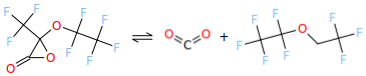

None


In [5]:
dep = database.kinetics.families['1+2_Cycloaddition'].get_training_depository()

for _, entry in dep.entries.items(): 
    if _==29: 
        rxn_to_play_with = entry
        print(display(entry.item))

In [6]:
problem_rxn = rxn_to_play_with.item

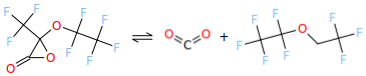

In [7]:
problem_rxn

In [8]:
fam_rxn_list = database.kinetics.generate_reactions_from_families(
                reactants=problem_rxn.reactants,
                products=problem_rxn.products,
                only_families=PFAS_families,
                resonance=False,
            )

ERROR:root:Could not update atomtypes for this molecule:
multiplicity -187
1  *3 F u0 p2 c0 {11,S} {13,S} {16,S}
2     F u0 p3 c0 {13,S}
3     F u0 p3 c0 {15,S}
4     F u0 p3 c0 {15,S}
5     F u0 p3 c0 {15,S}
6     F u0 p3 c0 {14,S}
7     F u0 p3 c0 {14,S}
8     F u0 p3 c0 {14,S}
9     O u0 p2 c0 {12,S} {13,S}
10    O u0 p2 c0 {12,S} {16,S}
11 *1 O u0 p2 c0 {1,S} {16,S}
12    C u0 p0 c0 {9,S} {10,S} {14,S} {16,S}
13    C u0 p0 c0 {1,S} {2,S} {9,S} {15,S}
14    C u0 p0 c0 {6,S} {7,S} {8,S} {12,S}
15    C u0 p0 c0 {3,S} {4,S} {5,S} {13,S}
16 *2 C u0 p0 c0 {1,S} {10,S} {11,S} {12,S}

ERROR:root:Could not update atomtypes for this molecule:
multiplicity -187
1     F u0 p3 c0 {13,S}
2  *3 F u0 p2 c0 {11,S} {13,S} {16,S}
3     F u0 p3 c0 {15,S}
4     F u0 p3 c0 {15,S}
5     F u0 p3 c0 {15,S}
6     F u0 p3 c0 {14,S}
7     F u0 p3 c0 {14,S}
8     F u0 p3 c0 {14,S}
9     O u0 p2 c0 {12,S} {13,S}
10    O u0 p2 c0 {12,S} {16,S}
11 *1 O u0 p2 c0 {2,S} {16,S}
12    C u0 p0 c0 {9,S} {10,S} {14,S} {1

In [28]:
database.kinetics.families['1+2_Cycloaddition'].add_atom_labels_for_reaction(fam_rxn_list[0])

ERROR:root:Could not update atomtypes for this molecule:
multiplicity -187
1  *1 O u0 p2 c0 {3,S} {4,S}
2     O u0 p2 c0 {3,D}
3  *2 C u0 p0 c0 {1,S} {2,D} {4,S}
4  *3 F u0 p2 c0 {1,S} {3,S} {13,S}
5     F u0 p3 c0 {13,S}
6     F u0 p3 c0 {14,S}
7     F u0 p3 c0 {14,S}
8     F u0 p3 c0 {14,S}
9     F u0 p3 c0 {15,S}
10    F u0 p3 c0 {15,S}
11    F u0 p3 c0 {15,S}
12    O u0 p2 c0 {13,S} {16,S}
13    C u0 p0 c0 {4,S} {5,S} {12,S} {14,S}
14    C u0 p0 c0 {6,S} {7,S} {8,S} {13,S}
15    C u0 p0 c0 {9,S} {10,S} {11,S} {16,S}
16    C u0 p1 c0 {12,S} {15,S}

ERROR:root:Could not update atomtypes for this molecule:
multiplicity -187
1  *1 O u0 p2 c0 {3,S} {5,S}
2     O u0 p2 c0 {3,D}
3  *2 C u0 p0 c0 {1,S} {2,D} {5,S}
4     F u0 p3 c0 {13,S}
5  *3 F u0 p2 c0 {1,S} {3,S} {13,S}
6     F u0 p3 c0 {14,S}
7     F u0 p3 c0 {14,S}
8     F u0 p3 c0 {14,S}
9     F u0 p3 c0 {15,S}
10    F u0 p3 c0 {15,S}
11    F u0 p3 c0 {15,S}
12    O u0 p2 c0 {13,S} {16,S}
13    C u0 p0 c0 {4,S} {5,S} {12,S} {14,S}
14

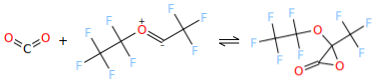

In [34]:
fam_rxn_list[0]

1 *1 O u0 p2 c0 {3,D}
2    O u0 p2 c0 {3,D}
3 *2 C u0 p0 c0 {1,D} {2,D}



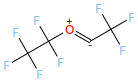

1     F u0 p3 c0 {10,S}
2     F u0 p3 c0 {10,S}
3     F u0 p3 c0 {11,S}
4     F u0 p3 c0 {11,S}
5     F u0 p3 c0 {11,S}
6     F u0 p3 c0 {12,S}
7     F u0 p3 c0 {12,S}
8     F u0 p3 c0 {12,S}
9     O u0 p1 c+1 {10,S} {13,D}
10    C u0 p0 c0 {1,S} {2,S} {9,S} {11,S}
11    C u0 p0 c0 {3,S} {4,S} {5,S} {10,S}
12    C u0 p0 c0 {6,S} {7,S} {8,S} {13,S}
13 *3 C u0 p1 c-1 {9,D} {12,S}


1     F u0 p3 c0 {10,S}
2     F u0 p3 c0 {10,S}
3     F u0 p3 c0 {11,S}
4     F u0 p3 c0 {11,S}
5     F u0 p3 c0 {11,S}
6     F u0 p3 c0 {12,S}
7     F u0 p3 c0 {12,S}
8     F u0 p3 c0 {12,S}
9     O u0 p2 c0 {10,S} {13,S}
10    C u0 p0 c0 {1,S} {2,S} {9,S} {11,S}
11    C u0 p0 c0 {3,S} {4,S} {5,S} {10,S}
12    C u0 p0 c0 {6,S} {7,S} {8,S} {13,S}
13 *3 C u0 p1 c0 {9,S} {12,S}



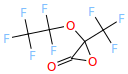

1     F u0 p3 c0 {13,S}
2     F u0 p3 c0 {13,S}
3     F u0 p3 c0 {15,S}
4     F u0 p3 c0 {15,S}
5     F u0 p3 c0 {15,S}
6     F u0 p3 c0 {14,S}
7     F u0 p3 c0 {14,S}
8     F u0 p3 c0 {14,S}
9     O u0 p2 c0 {12,S} {13,S}
10 *1 O u0 p2 c0 {12,S} {16,S}
11    O u0 p2 c0 {16,D}
12 *3 C u0 p0 c0 {9,S} {10,S} {14,S} {16,S}
13    C u0 p0 c0 {1,S} {2,S} {9,S} {15,S}
14    C u0 p0 c0 {6,S} {7,S} {8,S} {12,S}
15    C u0 p0 c0 {3,S} {4,S} {5,S} {13,S}
16 *2 C u0 p0 c0 {10,S} {11,D} {12,S}



In [30]:
for spec in fam_rxn_list[0].reactants + fam_rxn_list[0].products:
    display(spec)
    print(spec.to_adjacency_list())

In [ ]:
for spec in problem_rxn.reactants + problem_rxn.products: 
    spec.generate_resonance_structures()
    print(spec.molecule)
    display(problem_rxn)
    

In [ ]:
problem_rxn.products[1].molecule[1].reactive

In [ ]:
problem_rxn

In [ ]:
problem_rxn.products[1].molecule[1].reactive

In [ ]:
fam_rxn_list = database.kinetics.generate_reactions_from_families(
                reactants=problem_rxn.reactants,
                products=problem_rxn.products,
                only_families=PFAS_families,
                resonance=True,
            )

In [ ]:
print(fam_rxn_list[0].reactants[0].to_adjacency_list())

In [ ]:
print(problem_rxn.products[1].to_adjacency_list())

In [ ]:
print(problem_rxn.products[0].to_adjacency_list())

In [ ]:
print(problem_rxn.reactants[0].to_adjacency_list())